# DeepL: 从零开始构建深度学习框架

## 📖 项目简介

本 Notebook 将带你从零开始构建一个简单的深度学习框架，核心目标是理解**自动微分（Automatic Differentiation）**和**计算图（Computational Graph）**的工作原理。

## 🎯 学习目标

通过本教程，你将学会：
1. **理解计算图的基本概念** - 了解深度学习框架如何追踪计算过程
2. **实现自动微分机制** - 理解反向传播算法的基础
3. **可视化计算图结构** - 直观地看到数据如何在计算图中流动
4. **掌握运算符重载** - 理解 Python 的特殊方法如何让自定义对象支持数学运算

## 📚 学习路径说明

本教程采用**循序渐进**的方式，从简单到复杂：

### 第一阶段：环境准备（第一章）
- 导入必要的库（numpy, matplotlib）
- 安装和配置 graphviz（用于可视化）

### 第二阶段：构建基础 Value 类（第二章）
- **2.1** 创建最简单的 Value 类，只存储数值
- **2.2** 添加运算符重载，让 Value 对象支持 `+`、`*` 等运算
- **2.3** 添加 `_prev` 和 `_op` 属性，构建计算图结构

### 第三阶段：可视化计算图（第三章）
- **3.1** 实现 `trace` 函数，遍历计算图收集节点和边
- **3.2** 实现 `draw_dot` 函数，将计算图可视化

### 第四阶段：深入理解（第四章）
- 探索计算图的属性
- 理解数据流向和节点关系

## 🚀 使用说明

- **按顺序运行**：请按照章节顺序运行每个单元格（`Shift + Enter`）
- **理解再继续**：确保理解当前章节的内容后再继续下一章节
- **动手实践**：尝试修改代码，观察结果变化

# 第一章：环境准备

在开始构建深度学习框架之前，我们需要准备必要的工具和库。

## 为什么需要这些库？

- **numpy**: 提供高效的数值计算功能（虽然本教程主要用 Python 原生类型，但 numpy 是深度学习的基础）
- **matplotlib**: 用于数据可视化（虽然本教程主要用 graphviz，但 matplotlib 是常用的可视化工具）
- **graphviz**: 用于可视化计算图结构，这是理解自动微分的关键工具

## 学习目标
- 了解项目所需的依赖
- 学会安装和导入必要的库

## 1.1 导入基础库

运行下面的单元格导入 numpy、matplotlib 和 math 库。

这些库虽然在本教程的前期不会直接使用，但它们是数据科学和深度学习的基础工具。

## 1.2 安装和导入 graphviz

**graphviz** 是本教程的核心可视化工具。它将帮助我们：
- 直观地看到计算图的结构
- 理解数据如何在节点之间流动
- 验证我们的 Value 类是否正确构建了计算图

### 安装步骤：
1. 先运行下面的安装单元格（如果 graphviz 未安装）
2. 如果安装成功，可能需要重启 kernel
3. 然后运行导入单元格

**注意**：graphviz 需要系统级的 graphviz 软件支持。如果遇到问题，请先安装系统级的 graphviz：
- macOS: `brew install graphviz`
- Ubuntu: `sudo apt-get install graphviz` 

1.1 BASIC Library 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math 

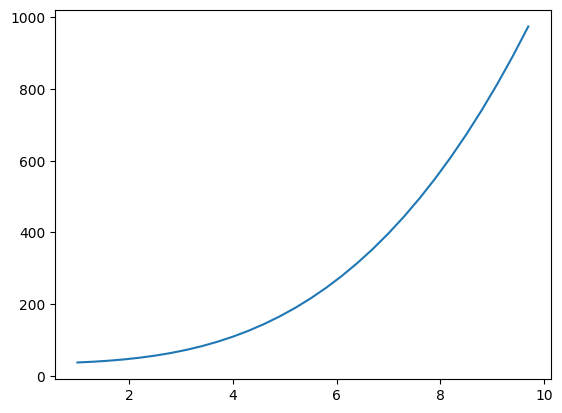

In [ ]:
a=np.arange(1,10,0.3)
y=a**3+3*a+33
plt.plot(a,y)
plt.show()

# 第二章：构建 Value 类 - 计算图的基础

## 为什么需要 Value 类？

在深度学习中，我们需要追踪每个计算步骤，以便进行反向传播（计算梯度）。传统的 Python 数值类型（如 `int`、`float`）无法做到这一点。

**Value 类的作用**：
- 存储数值（`data` 属性）
- 记录计算历史（`_prev` 属性，存储操作数的来源）
- 记录操作类型（`_op` 属性，如 `+`、`*` 等）

## 学习路径

我们将分三步构建 Value 类：

1. **最简单的版本**：只存储数值，不支持运算
2. **添加运算符重载**：让 Value 对象支持 `+`、`*` 等运算
3. **添加计算图追踪**：通过 `_prev` 和 `_op` 记录计算历史

这样循序渐进的方式可以帮助你理解每个部分的作用。

## 2.1 第一步：最简单的 Value 类

这是 Value 类的最基础版本，它只做一件事：**存储一个数值**。

### 代码说明：
- `__init__`: 初始化方法，接收一个 `data` 参数并存储
- `__repr__`: 定义对象的字符串表示，方便调试

### 为什么从这里开始？

在添加复杂功能之前，我们先确保基础结构正确。这个简单版本让我们可以：
- 创建 Value 对象
- 访问和查看存储的数值
- 为后续添加功能打好基础

运行下面的单元格，看看最简单的 Value 类是如何工作的。

## 2.2 第二步：添加运算符重载

现在我们要让 Value 对象支持数学运算（如 `+`、`*`）。

### 关键概念：运算符重载

当你写 `a + b` 时，Python 会自动调用 `a.__add__(b)`。这就是**运算符重载**机制。

### 代码说明：
- `__add__`: 定义 `+` 运算符的行为
- `__mul__`: 定义 `*` 运算符的行为

### 当前版本的限制：

这个版本虽然可以进行运算，但**无法追踪计算历史**。我们不知道：
- 结果是如何计算出来的
- 参与了哪些运算
- 操作数是什么

**下一步**：我们将添加 `_prev` 和 `_op` 属性来解决这个问题。

In [7]:
class Value:
    def __init__(self, data):
        self.data= data
    
    def __repr__(self):
        return f"data={self.data}"
    
    def __add__(self, other):
        return Value(self.data + other.data)

    def __mul__(self, other):
        return Value(self.data * other.data) # u can only run a*b with this method statement

a=Value(1)
b=Value(2)


## 2.3 第三步：完整的 Value 类实现

这是 Value 类的**完整版本**，它能够追踪完整的计算历史，并为自动微分做好准备。

### 完整的属性列表：

1. **`data`**: 存储节点的数值
2. **`_prev`** (来自 `_children` 参数):
   - 存储**父节点集合**（操作数的来源）
   - 使用 `set()` 自动去重
   - 例如：`c = a * b` 中，`c._prev = {a, b}`
   - **重要**：如果两个操作数是同一个对象（如 `c * c`），集合会自动去重，只保留一个

3. **`_op`**:
   - 存储**操作符类型**（如 `'+'`、`'*'`、`'-'` 等）
   - 空字符串 `''` 表示这是输入节点（不是运算结果）

4. **`label`** (新增):
   - 节点的标签，用于标识和调试
   - 方便在可视化时识别不同的节点
   - 例如：`a = Value(1, label='a')`

5. **`grad`** (新增):
   - 存储梯度值，用于反向传播
   - 初始化为 `0`
   - 这是自动微分的核心属性

### 支持的运算符：

- `+` (加法): `__add__`
- `-` (减法): `__sub__`
- `*` (乘法): `__mul__`

### 为什么需要这些属性？

有了这些属性，我们可以：
- **重建整个计算表达式**：从结果追溯到所有输入
- **构建计算图**：理解数据如何流动
- **实现自动微分**：通过 `grad` 属性存储和传播梯度
- **可视化计算图**：通过 `label` 更好地标识节点

### 示例理解：

```python
a = Value(1, label='a')      # a._prev = set(), a._op = '', a.grad = 0
b = Value(2, label='b')      # b._prev = set(), b._op = '', b.grad = 0
c = a + b                    # c._prev = {a, b}, c._op = '+', c.grad = 0
c.label = 'c'                # 设置标签
e = c * c                    # e._prev = {c} (注意：集合去重，只有一个c)
e.label = 'e'                # e.data = 9, e._op = '*'
```

运行下面的单元格，查看完整的 Value 类实现。

In [29]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data= data
        self._prev= set(_children)
        self._op= _op
        self.label= label
        self.grad= 0

    def __repr__(self):
        return f"data={self.data}, label={self.label}"
    
    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')

    def __sub__(self, other):
        return Value(self.data - other.data, (self, other), '-')
    
    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')
        
    
    
    


## 2.4 数值微分验证

在实现自动微分之前，让我们先用**数值微分**的方法来验证我们的计算是否正确。

### 什么是数值微分？

数值微分通过微小的扰动来近似计算导数：
```
f'(x) ≈ (f(x + h) - f(x)) / h
```
其中 `h` 是一个非常小的数（如 0.0001）。

### 示例：计算 e = (a + b)² 对 a 的导数

我们的计算：
- `c = a + b`，其中 `a = 1`, `b = 2`，所以 `c = 3`
- `e = c * c = c² = 9`

理论导数：
- `e = (a + b)²`
- `de/da = 2(a + b) = 2(1 + 2) = 6`

数值微分验证：
- 将 `a` 增加 `h = 0.0001`
- 重新计算 `e`，得到 `H2`
- 计算 `(H2 - H1) / h`，应该接近 `6`

运行下面的单元格，看看数值微分的结果是否接近理论值 `6`。

In [30]:
def lol():
    h=0.0001
    a=Value(1, label='a')
    b=Value(2, label='b')
    c=a+b; c.label= 'c'
    e=c*c; e.label= 'e'
    H1=e.data

    a=Value(1+h, label='a')
    b=Value(2, label='b')
    c=a+b; c.label= 'c'
    e=c*c; e.label= 'e'
    H2=e.data

    print((H2-H1)/h) 
    
lol()

6.000099999994291


## 2.5 测试 Value 类的计算图追踪

让我们创建一个计算示例来测试 Value 类的功能。

### 示例计算：e = (a + b)²

```python
a = Value(1, label='a')
b = Value(2, label='b')
c = a + b        # c = 3
c.label = 'c'
e = c * c        # e = 9
e.label = 'e'
```

### 观察要点：

1. **`e._prev` 的内容**：
   - `e = c * c` 的两个操作数都是 `c`
   - 由于 `_prev` 是集合（`set()`），会自动去重
   - 所以 `e._prev = {c}` 而不是 `{c, c}`
   - 输出显示：`{data=3, label=c}`

2. **`__repr__` 方法**：
   - 显示 `data` 和 `label` 信息
   - 格式：`data={self.data}, label={self.label}`

3. **计算图结构**：
   ```
   a (data=1) ──┐
                ├─→ c (data=3, _op='+') ──→ e (data=9, _op='*')
   b (data=2) ──┘                           ↑
                                            │
                                            └─── (c * c)
   ```

运行下面的单元格，查看 `e._prev` 的内容。

### 深入理解 `_prev` 集合的行为

**重要发现**：当两个操作数是同一个对象时，集合会自动去重！

### 示例分析：

```python
e = c * c  # 两个操作数都是 c
e._prev   # 输出：{data=3, label=c}
```

**为什么只有一个元素？**

- `e._prev` 是 `set({c, c})`
- Python 的 `set()` 会自动去除重复元素
- 所以 `{c, c}` 变成了 `{c}`
- 这就是为什么输出只显示一个 `c` 对象

### 验证方法：

你可以通过以下方式验证：

```python
print(f"e._prev 的长度: {len(e._prev)}")  # 输出: 1
print(f"e._prev 的内容: {e._prev}")        # 输出: {data=3, label=c}
```

### 思考题：

- 如果 `e = a * b`（两个不同的对象），`e._prev` 会包含几个元素？
- 集合去重对计算图有什么影响？
- 为什么使用 `set()` 而不是 `list()` 来存储 `_prev`？

In [31]:
a=Value(1, label='a')
b=Value(2, label='b')
c=a+b; c.label= 'c'
e=c*c; e.label= 'e'
e._prev

{data=3, label=c}

# 第三章：可视化计算图

## 为什么需要可视化？

虽然我们可以通过 `_prev` 和 `_op` 属性查看计算图的结构，但这不够直观。可视化可以帮助我们：
- **直观理解**：一眼看到整个计算流程
- **验证正确性**：确认计算图是否正确构建
- **调试问题**：快速发现代码中的错误

## 可视化工具的工作原理

我们将实现两个函数：

1. **`trace` 函数**：
   - 从根节点（最终结果）开始
   - 递归遍历所有父节点
   - 收集所有节点和连接关系

2. **`draw_dot` 函数**：
   - 使用 graphviz 创建图形
   - 为每个节点绘制矩形（数据值）
   - 为每个操作符绘制圆形（运算类型）
   - 用箭头表示数据流向

## 学习目标

- 理解如何遍历计算图
- 学会使用 graphviz 绘制图形
- 能够解释可视化结果的含义

## 3.1 实现可视化工具函数

下面我们实现两个核心函数来可视化计算图。

### `trace` 函数：遍历计算图

**作用**：从根节点开始，递归地收集所有节点和连接关系。

**工作原理**：
1. 从最终结果（根节点）开始
2. 访问当前节点的所有父节点（`_prev`）
3. 记录节点和边的关系
4. 递归访问父节点的父节点，直到所有节点都被访问

**为什么需要递归？**
- 计算图是树状结构
- 一个节点可能有多个父节点
- 需要遍历整个树才能收集所有信息

### `draw_dot` 函数：绘制图形

**作用**：使用 graphviz 将计算图绘制成可视化的图形。

**绘制步骤**：
1. 为每个 Value 对象创建矩形节点（显示数据值）
2. 为每个操作符创建圆形节点（显示运算类型）
3. 连接操作符节点到数据节点（表示运算产生数据）
4. 连接数据节点到操作符节点（表示数据流向）

运行下面的单元格，导入 graphviz 并定义这两个函数。

In [ ]:
# 安装 graphviz（如果还没有安装的话）
# 注意：如果遇到 ModuleNotFoundError，请先运行这个单元格安装 graphviz
# 安装完成后，可能需要重启 kernel（Kernel -> Restart Kernel）
import sys
!{sys.executable} -m pip install graphviz

In [35]:
# 导入 graphviz 用于可视化
from graphviz import Digraph
print("✓ graphviz 导入成功！")


# ============================================================================
# trace 函数：遍历计算图，收集所有节点和边
# ============================================================================
def trace(root):
    """
    遍历计算图，收集所有节点和边
    
    参数：
        root: 计算图的根节点（最终的计算结果）
    返回：
        nodes: 所有节点的集合
        edges: 所有边的集合，每个边是 (子节点, 父节点) 的元组
    """
    nodes, edges = set(), set()
    
    def build(v):
        """递归遍历计算图的辅助函数"""
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))  # 从子节点指向父节点
                build(child)
    
    build(root)
    return nodes, edges


# ============================================================================
# draw_dot 函数：将计算图绘制成可视化的图形
# ============================================================================
def draw_dot(root):
    """
    将计算图绘制成可视化的图形
    
    参数：
        root: 计算图的根节点
    返回：
        dot: Digraph 对象，可以调用 .render() 生成图片
    """
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # 从左到右
    nodes, edges = trace(root)
    
    # 为每个节点创建图形元素
    for n in nodes:
        uid = str(id(n))
        # 数据节点（矩形）- 显示 label、data 和 grad
        # 构建标签字符串
        label_parts = []
        if n.label:
            label_parts.append(f"label: {n.label}")
        label_parts.append(f"data: {n.data:.4f}")
        label_parts.append(f"grad: {n.grad:.4f}")
        label_str = "|".join(label_parts)
        dot.node(name=uid, label=f"{{ {label_str} }}", shape='record')
        
        # 操作符节点（圆形）
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)  # 操作符 -> 数据节点
    
    # 连接节点之间的边（数据流向）
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)  # 子节点 -> 父节点的操作符
    
    return dot

✓ graphviz 导入成功！


## 3.2 可视化示例

现在让我们可视化之前创建的计算图 `d = a + b + c`（其中 `c = a * b`）。

### 如何阅读可视化结果？

- **矩形节点**：表示数据值（Value 对象）
- **圆形节点**：表示运算操作符（`+`、`*` 等）
- **箭头**：表示数据流向（从操作数指向运算结果）

### 预期结果：

你应该看到一个从左到右的图形，显示：
1. 左侧：输入节点 `a` 和 `b`（没有操作符）
2. 中间：`a * b` 的运算（`*` 操作符指向结果 `c`）
3. 右侧：`a + b + c` 的运算（`+` 操作符指向最终结果 `d`）

**注意**：如果遇到 `NameError: name 'd' is not defined`，请先运行第二章的单元格创建 `a`、`b`、`c`、`d` 对象。

运行下面的单元格来可视化计算图。

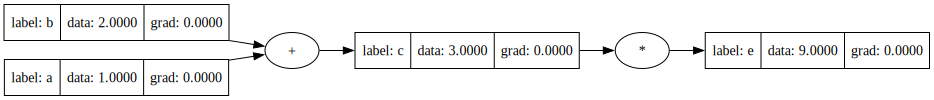

In [37]:
a=Value(1, label='a')
b=Value(2, label='b')
c=a+b; c.label= 'c'
e=c*c; e.label= 'e'
e._prev
draw_dot(e)

# 第四章：深入理解计算图与自动微分

## 4.1 计算图结构解析

通过前面的学习和实践，我们已经构建了完整的计算图系统。现在让我们深入理解每个部分的作用。

### 计算图的关键概念

1. **节点（Node）**：
   - **数据节点**：存储数值的 Value 对象（矩形显示）
   - **操作符节点**：表示运算类型（`+`、`*`、`-` 等，圆形显示）

2. **边（Edge）**：
   - 表示数据流向
   - 从操作数指向运算结果
   - 箭头方向表示计算依赖关系

3. **计算流程示例**：
   ```
   e = (a + b)²
   
   步骤1: a (data=1) ──┐
         b (data=2) ──┼─→ c (data=3, _op='+')
                     │
   步骤2: c (data=3) ──┼─→ e (data=9, _op='*')
         c (data=3) ──┘   (注意：集合去重，e._prev = {c})
   ```

### 为什么需要计算图？

计算图是自动微分的基础：
- **前向传播（Forward Pass）**：按照计算图从输入到输出计算最终结果
- **反向传播（Backward Pass）**：沿着计算图从输出到输入计算梯度
- **梯度存储**：每个节点的 `grad` 属性存储该节点对最终结果的梯度

### Value 类的完整属性说明

1. **`data`**：节点的数值
   - 存储计算结果
   - 在前向传播中计算

2. **`_prev`**：父节点集合
   - 存储操作数的来源
   - 使用 `set()` 自动去重
   - 用于反向传播时遍历计算图

3. **`_op`**：操作符类型
   - 标识运算类型（`'+'`、`'*'`、`'-'` 等）
   - 空字符串表示输入节点
   - 用于反向传播时选择正确的梯度计算规则

4. **`label`**：节点标签
   - 用于标识和调试
   - 方便在可视化时识别节点
   - 可选属性

5. **`grad`**：梯度值
   - 存储该节点对最终结果的梯度
   - 初始化为 `0`
   - 在反向传播中计算和更新
   - **这是自动微分的核心**

### 下一步：实现反向传播

现在我们已经有了：
- ✅ 计算图结构（`_prev`、`_op`）
- ✅ 前向传播（运算符重载）
- ✅ 可视化工具（`draw_dot`）
- ✅ 数值微分验证（`lol()` 函数）

接下来我们将实现：
- 🔜 反向传播算法
- 🔜 自动计算梯度
- 🔜 验证自动微分结果与数值微分一致

### 总结

通过本章的学习，我们理解了：
- 计算图如何存储计算历史
- `_prev` 集合的去重行为
- `label` 和 `grad` 属性的作用
- 数值微分如何验证我们的计算

这些知识为下一章实现自动微分打下了坚实的基础。

# 第五章：反向传播与链式法则

## 5.1 理解局部梯度和全局梯度

在自动微分中，我们使用**链式法则（Chain Rule）**来计算梯度。

### 关键概念：

1. **局部梯度（Local Gradient）**：
   - 每个操作对其输入的直接导数
   - 例如：对于 `c = a + b`，局部梯度是 `∂c/∂a = 1` 和 `∂c/∂b = 1`
   - 例如：对于 `c = a * b`，局部梯度是 `∂c/∂a = b` 和 `∂c/∂b = a`

2. **全局梯度（Global Gradient）**：
   - 最终输出对某个节点的梯度
   - 通过链式法则从局部梯度传播得到
   - 公式：`∂L/∂x = ∂L/∂y * ∂y/∂x`（其中 L 是最终损失，y 是中间节点）

3. **链式法则（Chain Rule）**：
   - 如果 `z = f(y)` 且 `y = g(x)`，那么 `dz/dx = dz/dy * dy/dx`
   - 在计算图中，我们从输出节点开始，反向传播梯度

### 反向传播算法：

1. **初始化**：最终节点的梯度设为 1（`output.grad = 1`）
2. **反向遍历**：从输出节点开始，按照拓扑顺序反向遍历所有节点
3. **梯度传播**：对每个节点，根据其操作类型计算局部梯度，然后传播给子节点

运行下面的单元格，查看完整的反向传播实现和复杂示例。

## 5.2 实现反向传播方法

我们需要在 Value 类中添加 `backward()` 方法来实现反向传播。

### 关键步骤：

1. **拓扑排序**：按照依赖关系排序节点（从叶子节点到根节点）
2. **初始化梯度**：根节点（输出）的梯度设为 1
3. **反向传播**：从根节点开始，根据操作类型计算局部梯度并传播

### 各操作的局部梯度：

- **加法** (`+`): `c = a + b` → `∂c/∂a = 1`, `∂c/∂b = 1`
- **乘法** (`*`): `c = a * b` → `∂c/∂a = b`, `∂c/∂b = a`
- **减法** (`-`): `c = a - b` → `∂c/∂a = 1`, `∂c/∂b = -1`

运行下面的单元格，查看完整的实现。

In [38]:
# 扩展 Value 类，添加反向传播方法
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None  # 默认的 backward 函数（叶子节点）

    def __repr__(self):
        return f"data={self.data}, label={self.label}"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            # 局部梯度：∂(a+b)/∂a = 1, ∂(a+b)/∂b = 1
            self.grad += out.grad * 1.0  # 链式法则：全局梯度 = 局部梯度 * 上游梯度
            other.grad += out.grad * 1.0
        out._backward = _backward
        
        return out

    def __sub__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data - other.data, (self, other), '-')
        
        def _backward():
            # 局部梯度：∂(a-b)/∂a = 1, ∂(a-b)/∂b = -1
            self.grad += out.grad * 1.0
            other.grad += out.grad * -1.0
        out._backward = _backward
        
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            # 局部梯度：∂(a*b)/∂a = b, ∂(a*b)/∂b = a
            self.grad += out.grad * other.data  # 链式法则
            other.grad += out.grad * self.data
        out._backward = _backward
        
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "只支持常数次幂"
        out = Value(self.data ** other, (self,), f'**{other}')
        
        def _backward():
            # 局部梯度：∂(x^n)/∂x = n * x^(n-1)
            self.grad += out.grad * (other * (self.data ** (other - 1)))
        out._backward = _backward
        
        return out
    
    def backward(self):
        """反向传播：计算所有节点的梯度"""
        # 拓扑排序：构建从叶子到根的顺序
        topo = []
        visited = set()
        
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        
        build_topo(self)
        
        # 初始化：输出节点的梯度为 1
        self.grad = 1.0
        
        # 反向传播：从输出节点开始，反向遍历
        for node in reversed(topo):
            node._backward()
    
    def __rmul__(self, other):
        return self * other
    
    def __radd__(self, other):
        return self + other

## 5.3 复杂示例：使用链式法则计算梯度

让我们创建一个复杂的计算图：`f = (a + b) * (c - d) + e^2`

### 计算图结构：
```
a ──┐
    ├─→ (a+b) ──┐
b ──┘           │
                ├─→ (a+b)*(c-d) ──┐
c ──┐           │                 │
    ├─→ (c-d) ──┘                 ├─→ f = (a+b)*(c-d) + e²
d ──┘                            │
                                 │
e ──→ e² ────────────────────────┘
```

### 手动计算梯度（验证用）：

假设 `a=2, b=3, c=5, d=1, e=4`，则：
- `f = (2+3) * (5-1) + 4² = 5 * 4 + 16 = 36`

梯度计算：
- `∂f/∂a = (c-d) = 4`
- `∂f/∂b = (c-d) = 4`
- `∂f/∂c = (a+b) = 5`
- `∂f/∂d = -(a+b) = -5`
- `∂f/∂e = 2*e = 8`

运行下面的单元格，看看自动微分的结果是否与手动计算一致。

前向传播结果: f = 36.0
预期结果: f = (2+3)*(5-1) + 4² = 5*4 + 16 = 36

梯度计算结果（使用链式法则）:
∂f/∂a = 4.0000 (预期: 4.0)
∂f/∂b = 4.0000 (预期: 4.0)
∂f/∂c = 5.0000 (预期: 5.0)
∂f/∂d = -5.0000 (预期: -5.0)
∂f/∂e = 8.0000 (预期: 8.0)

中间节点的梯度:
∂f/∂(a+b) = 4.0000
∂f/∂(c-d) = 5.0000
∂f/∂((a+b)*(c-d)) = 1.0000
∂f/∂(e²) = 1.0000

计算图可视化（包含梯度）:


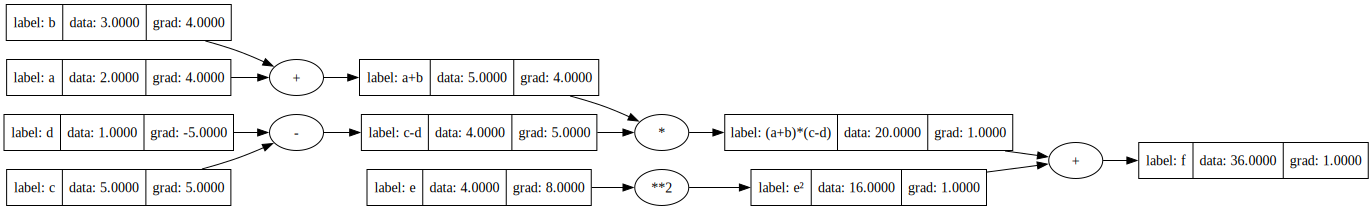

In [39]:
# 复杂示例：f = (a + b) * (c - d) + e^2
a = Value(2.0, label='a')
b = Value(3.0, label='b')
c = Value(5.0, label='c')
d = Value(1.0, label='d')
e = Value(4.0, label='e')

# 构建计算图
ab_sum = a + b
ab_sum.label = 'a+b'

cd_diff = c - d
cd_diff.label = 'c-d'

product = ab_sum * cd_diff
product.label = '(a+b)*(c-d)'

e_squared = e ** 2
e_squared.label = 'e²'

f = product + e_squared
f.label = 'f'

print(f"前向传播结果: f = {f.data}")
print(f"预期结果: f = (2+3)*(5-1) + 4² = 5*4 + 16 = 36")
print()

# 反向传播
f.backward()

# 显示所有节点的梯度
print("=" * 60)
print("梯度计算结果（使用链式法则）:")
print("=" * 60)
print(f"∂f/∂a = {a.grad:.4f} (预期: 4.0)")
print(f"∂f/∂b = {b.grad:.4f} (预期: 4.0)")
print(f"∂f/∂c = {c.grad:.4f} (预期: 5.0)")
print(f"∂f/∂d = {d.grad:.4f} (预期: -5.0)")
print(f"∂f/∂e = {e.grad:.4f} (预期: 8.0)")
print()

# 显示中间节点的梯度
print("中间节点的梯度:")
print(f"∂f/∂(a+b) = {ab_sum.grad:.4f}")
print(f"∂f/∂(c-d) = {cd_diff.grad:.4f}")
print(f"∂f/∂((a+b)*(c-d)) = {product.grad:.4f}")
print(f"∂f/∂(e²) = {e_squared.grad:.4f}")
print()

# 可视化计算图（包含梯度）
print("计算图可视化（包含梯度）:")
draw_dot(f)

## 5.4 理解链式法则的工作原理

让我们详细分析梯度是如何通过链式法则传播的：

### 梯度传播路径：

1. **初始化**：`f.grad = 1.0`（输出节点）

2. **从 f 到 product 和 e_squared**：
   - `f = product + e_squared`
   - 局部梯度：`∂f/∂product = 1`, `∂f/∂e_squared = 1`
   - 全局梯度：`product.grad = 1.0 * 1 = 1.0`
   - 全局梯度：`e_squared.grad = 1.0 * 1 = 1.0`

3. **从 product 到 ab_sum 和 cd_diff**：
   - `product = ab_sum * cd_diff`
   - 局部梯度：`∂product/∂ab_sum = cd_diff.data = 4`
   - 局部梯度：`∂product/∂cd_diff = ab_sum.data = 5`
   - 全局梯度：`ab_sum.grad = product.grad * cd_diff.data = 1.0 * 4 = 4.0`
   - 全局梯度：`cd_diff.grad = product.grad * ab_sum.data = 1.0 * 5 = 5.0`

4. **从 ab_sum 到 a 和 b**：
   - `ab_sum = a + b`
   - 局部梯度：`∂ab_sum/∂a = 1`, `∂ab_sum/∂b = 1`
   - 全局梯度：`a.grad = ab_sum.grad * 1 = 4.0 * 1 = 4.0`
   - 全局梯度：`b.grad = ab_sum.grad * 1 = 4.0 * 1 = 4.0`

5. **从 cd_diff 到 c 和 d**：
   - `cd_diff = c - d`
   - 局部梯度：`∂cd_diff/∂c = 1`, `∂cd_diff/∂d = -1`
   - 全局梯度：`c.grad = cd_diff.grad * 1 = 5.0 * 1 = 5.0`
   - 全局梯度：`d.grad = cd_diff.grad * (-1) = 5.0 * (-1) = -5.0`

6. **从 e_squared 到 e**：
   - `e_squared = e²`
   - 局部梯度：`∂e_squared/∂e = 2 * e = 2 * 4 = 8`
   - 全局梯度：`e.grad = e_squared.grad * 8 = 1.0 * 8 = 8.0`

### 关键洞察：

- **局部梯度**是每个操作对其输入的导数
- **全局梯度**通过链式法则累积：`全局梯度 = 上游梯度 × 局部梯度`
- 使用 `+=` 是因为一个节点可能被多个路径使用（如 `c * c`）

运行下面的单元格，查看详细的梯度传播过程。

In [40]:
# 详细展示梯度传播过程
def print_gradient_flow(root):
    """打印梯度传播的详细信息"""
    nodes, edges = trace(root)
    
    # 按拓扑顺序排序（从叶子到根）
    topo = []
    visited = set()
    
    def build_topo(v):
        if v not in visited:
            visited.add(v)
            for child in v._prev:
                build_topo(child)
            topo.append(v)
    
    build_topo(root)
    
    print("梯度传播顺序（从输出到输入）:")
    print("=" * 70)
    
    for i, node in enumerate(reversed(topo)):
        label = node.label if node.label else f"node_{id(node)}"
        print(f"\n步骤 {i+1}: {label}")
        print(f"  数据值: {node.data:.4f}")
        print(f"  梯度值: {node.grad:.4f}")
        if node._op:
            print(f"  操作: {node._op}")
            print(f"  父节点: {[c.label if c.label else f'node_{id(c)}' for c in node._prev]}")

# 重新运行示例
a = Value(2.0, label='a')
b = Value(3.0, label='b')
c = Value(5.0, label='c')
d = Value(1.0, label='d')
e = Value(4.0, label='e')

ab_sum = a + b; ab_sum.label = 'a+b'
cd_diff = c - d; cd_diff.label = 'c-d'
product = ab_sum * cd_diff; product.label = '(a+b)*(c-d)'
e_squared = e ** 2; e_squared.label = 'e²'
f = product + e_squared; f.label = 'f'

f.backward()
print_gradient_flow(f)

梯度传播顺序（从输出到输入）:

步骤 1: f
  数据值: 36.0000
  梯度值: 1.0000
  操作: +
  父节点: ['e²', '(a+b)*(c-d)']

步骤 2: (a+b)*(c-d)
  数据值: 20.0000
  梯度值: 1.0000
  操作: *
  父节点: ['a+b', 'c-d']

步骤 3: c-d
  数据值: 4.0000
  梯度值: 5.0000
  操作: -
  父节点: ['d', 'c']

步骤 4: c
  数据值: 5.0000
  梯度值: 5.0000

步骤 5: d
  数据值: 1.0000
  梯度值: -5.0000

步骤 6: a+b
  数据值: 5.0000
  梯度值: 4.0000
  操作: +
  父节点: ['a', 'b']

步骤 7: b
  数据值: 3.0000
  梯度值: 4.0000

步骤 8: a
  数据值: 2.0000
  梯度值: 4.0000

步骤 9: e²
  数据值: 16.0000
  梯度值: 1.0000
  操作: **2
  父节点: ['e']

步骤 10: e
  数据值: 4.0000
  梯度值: 8.0000


## Time to build a single neural node
### Activation Equation(sigmoid or tanh) + BackPropagation

In [ ]:
# Now we are going to write the new expression:



# BackPropagation
a.data += 0.01*a.grad
b.data += 0.01*b.grad
c.data += 0.01*c.grad
d.data += 0.01*d.grad
e.data += 0.01*e.grad

